In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import os
import pathlib

BASE_DIR = pathlib.Path(os.getcwd())
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

DB_PATH = BASE_DIR / 'data' / 'banco.db'
engine  = create_engine(f'sqlite:///{DB_PATH}', echo=False)

# Carrega sem as colunas de cluster que podem estar em tb_clientes
df_c  = pd.read_sql('SELECT * FROM tb_clientes', engine)
df_c  = df_c.drop(columns=['cluster_id','cluster_nome'], errors='ignore')

df_cl = pd.read_sql('SELECT id_cliente, cluster_id, cluster_nome FROM tb_clusters', engine)
df    = df_c.merge(df_cl, on='id_cliente', how='left')

NOMES_CLUSTERS = {
    0: 'Primeiros Passos',
    1: 'Trajetória Crescente',
    2: 'Potencial Oculto',
    3: 'Self Made',
    4: 'Old Money',
}

print(f"Clientes: {len(df):,} | Colunas: {len(df.columns)}")
print(f"cluster_nome nulos: {df['cluster_nome'].isnull().sum()}")
print(f"cluster_nome únicos: {df['cluster_nome'].unique()}")

Clientes: 300,000 | Colunas: 44
cluster_nome nulos: 0
cluster_nome únicos: <ArrowStringArray>
['Trajetória Crescente',     'Potencial Oculto',     'Primeiros Passos',
            'Self Made',            'Old Money']
Length: 5, dtype: str


In [2]:
# Recência — meses de relacionamento invertido
df['rfm_recencia'] = df['meses_relacionamento'].apply(
    lambda x: 5 if x <= 6 else 4 if x <= 24 else 3 if x <= 60 else 2 if x <= 120 else 1
)

# Frequência — transações mensais
df['rfm_frequencia'] = pd.qcut(
    df['media_transacoes_mes'], q=5, labels=[1,2,3,4,5]
).astype(int)

# Monetário — renda + saldo
df['valor_monetario'] = df['renda_mensal'] * 0.7 + df['saldo_medio'] * 0.3
df['rfm_monetario'] = pd.qcut(
    df['valor_monetario'], q=5, labels=[1,2,3,4,5]
).astype(int)

# Score RFM ponderado
df['rfm_score'] = (
    df['rfm_recencia']   * 0.30 +
    df['rfm_frequencia'] * 0.35 +
    df['rfm_monetario']  * 0.35
).round(4)

def segmento_rfm(score):
    if score >= 4.5:   return 'Champions'
    elif score >= 3.5: return 'Clientes Leais'
    elif score >= 2.5: return 'Potencial de Crescimento'
    elif score >= 1.5: return 'Em Risco'
    else:              return 'Perdidos'

df['rfm_segmento'] = df['rfm_score'].apply(segmento_rfm)

print("=== RFM CALCULADO ===")
print(df['rfm_segmento'].value_counts())
print(f"\nScore médio: {df['rfm_score'].mean():.2f}")
print(f"Missing values: {df.isnull().sum().sum()}")

=== RFM CALCULADO ===


rfm_segmento
Potencial de Crescimento    103466
Em Risco                     96772
Clientes Leais               66028
Perdidos                     33276
Champions                      458
Name: count, dtype: int64

Score médio: 2.72
Missing values: 0


=== DISTRIBUIÇÃO RFM POR CLUSTER (%) ===
rfm_segmento          Champions  Clientes Leais  Em Risco  Perdidos  \
cluster_nome                                                          
Old Money                   0.0            99.6       0.1       0.0   
Potencial Oculto            0.2            10.3      38.3      16.4   
Primeiros Passos            0.1             2.8      74.0       5.6   
Self Made                   0.1            49.4       1.3       0.0   
Trajetória Crescente        0.2             8.9      39.8      16.4   

rfm_segmento          Potencial de Crescimento  
cluster_nome                                    
Old Money                                  0.3  
Potencial Oculto                          34.8  
Primeiros Passos                          17.6  
Self Made                                 49.2  
Trajetória Crescente                      34.6  


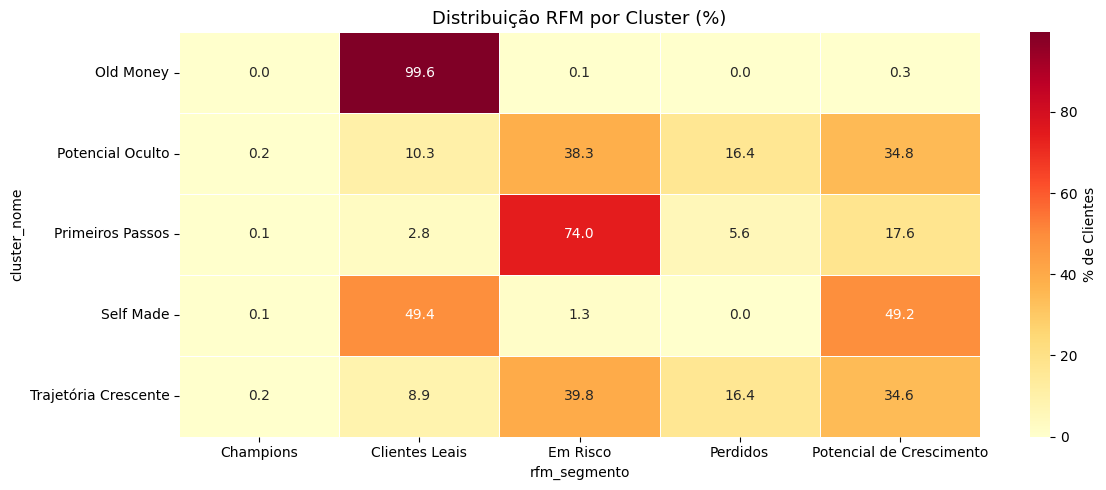

In [3]:
# Usa perfil_real como fallback se cluster_nome estiver nulo
if df['cluster_nome'].isnull().all():
    print("cluster_nome nulo — usando perfil_real como fallback")
    df['cluster_nome'] = df['perfil_real'].map({
        'primeiros_passos':    'Primeiros Passos',
        'trajetoria_crescente':'Trajetória Crescente',
        'potencial_oculto':    'Potencial Oculto',
        'self_made':           'Self Made',
        'old_money':           'Old Money',
    })

rfm_cluster = df.groupby(['cluster_nome','rfm_segmento']).size().unstack(fill_value=0)
rfm_cluster_pct = rfm_cluster.div(rfm_cluster.sum(axis=1), axis=0) * 100

print("=== DISTRIBUIÇÃO RFM POR CLUSTER (%) ===")
print(rfm_cluster_pct.round(1))

if rfm_cluster_pct.empty:
    print("DataFrame vazio — verifique cluster_nome!")
else:
    plt.figure(figsize=(12, 5))
    sns.heatmap(rfm_cluster_pct, annot=True, fmt='.1f',
                cmap='YlOrRd', linewidths=0.5,
                cbar_kws={'label': '% de Clientes'})
    plt.title('Distribuição RFM por Cluster (%)', fontsize=13)
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / 'docs' / 'rfm_clusters.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [4]:
with engine.connect() as conn:
    total = conn.execute(text("SELECT COUNT(*) FROM tb_clusters WHERE cluster_nome IS NOT NULL")).scalar()
    sample = conn.execute(text("SELECT * FROM tb_clusters LIMIT 3")).fetchall()
    print(f"tb_clusters com nome preenchido: {total:,}")
    print(f"Amostra: {sample}")

tb_clusters com nome preenchido: 300,000
Amostra: [('CLI000001', 1, 'Trajetória Crescente'), ('CLI000002', 2, 'Potencial Oculto'), ('CLI000003', 0, 'Primeiros Passos')]


In [5]:
df['prioridade_ataque'] = 'Baixa'

df.loc[
    (df['rfm_segmento'].isin(['Champions','Clientes Leais'])) &
    (df['cluster_nome'] == 'Old Money'),
    'prioridade_ataque'
] = 'Alta'

df.loc[
    (df['rfm_segmento'].isin(['Champions','Clientes Leais'])) &
    (df['cluster_nome'].isin(['Self Made','Potencial Oculto'])),
    'prioridade_ataque'
] = 'Média'

df.loc[
    df['rfm_segmento'].isin(['Em Risco','Perdidos']),
    'prioridade_ataque'
] = 'Retenção'

print("=== PRIORIDADE DE ATAQUE ===")
print(df['prioridade_ataque'].value_counts())

print("\n=== ALTA PRIORIDADE POR CLUSTER ===")
print(df[df['prioridade_ataque']=='Alta'].groupby('cluster_nome').size())

=== PRIORIDADE DE ATAQUE ===
prioridade_ataque
Retenção    130048
Baixa       113253
Média        41598
Alta         15101
Name: count, dtype: int64

=== ALTA PRIORIDADE POR CLUSTER ===
cluster_nome
Old Money    15101
dtype: int64


In [6]:
df['score_final'] = (
    df['rfm_score'] * 0.40 +
    (df['score_credito'] / 1000 * 5) * 0.30 +
    (df['qtd_produtos'] / df['qtd_produtos'].max() * 5) * 0.15 +
    (df['renda_mensal'] / df['renda_mensal'].max() * 5) * 0.15
).round(4)

print("=== TOP 10 CLIENTES ===")
top10 = df.nlargest(10, 'score_final')[[
    'id_cliente','cluster_nome','rfm_segmento',
    'renda_mensal','score_credito','rfm_score','score_final'
]]
print(top10.to_string(index=False))

=== TOP 10 CLIENTES ===
id_cliente cluster_nome   rfm_segmento  renda_mensal  score_credito  rfm_score  score_final
 CLI164830    Old Money Clientes Leais     120000.00            980        4.4       4.4573
 CLI094537    Old Money Clientes Leais     120000.00            995        4.1       4.4280
 CLI120857    Old Money Clientes Leais     120000.00            949        4.1       4.4271
 CLI007097    Old Money Clientes Leais     120000.00            985        4.1       4.4130
 CLI239755    Old Money Clientes Leais     120000.00            950        4.4       4.4123
 CLI209362    Old Money Clientes Leais     120000.00            936        4.1       4.4076
 CLI026232    Old Money Clientes Leais     118940.21            934        4.1       4.3980
 CLI145798    Old Money Clientes Leais     120000.00            975        4.1       4.3980
 CLI007430    Old Money Clientes Leais     120000.00            926        4.1       4.3926
 CLI118161    Old Money Clientes Leais     120000.00    